# Initial Data Collection and Exploration
This notebook guides the first steps of collecting, loading, and exploring stock market data (e.g., CAC40, S&P500).

## 1. Import the required libraries

In [ ]:
import pandas as pd
from pandas.plotting import autocorrelation_plot
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import grangercausalitytests
from arch import arch_model
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.fft import fft, fftfreq

# Optional: for displaying plots in the notebook
%matplotlib inline

## 2. Data collection from an external source
We will use yfinance to download historical data for CAC40 or S&P500.

In [ ]:
# Download S&P500 data (ticker '^GSPC') and CAC40 (ticker '^FCHI')
ticker_sp500 = '^GSPC'
ticker_cac40 = '^FCHI'

df_sp500 = yf.download(ticker_sp500, start='2015-01-01', end=None)
df_sp500.reset_index(inplace=True)
# Save the data to a CSV file and put it in data/raw
df_sp500.to_csv('../data/raw/sp500.csv', index=False)


df_cac40 = yf.download(ticker_cac40, start='2015-01-01', end=None)
df_cac40.reset_index(inplace=True)
# Save the data to a CSV file and put it in data/raw
df_cac40.to_csv('../data/raw/cac40.csv', index=False)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


## 4. Preview the first rows of the data

In [4]:
df_sp500.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
0,2015-01-02,2058.199951,2072.360107,2046.040039,2058.899902,2708700000
1,2015-01-05,2020.579956,2054.439941,2017.339966,2054.439941,3799120000
2,2015-01-06,2002.609985,2030.250000,1992.439941,2022.150024,4460110000
3,2015-01-07,2025.900024,2029.609985,2005.550049,2005.550049,3805480000
4,2015-01-08,2062.139893,2064.080078,2030.609985,2030.609985,3934010000


In [5]:
df_cac40.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,^FCHI,^FCHI,^FCHI,^FCHI,^FCHI
0,2015-01-02,4252.290039,4311.000000,4224.339844,4294.049805,69809300
1,2015-01-05,4111.359863,4276.919922,4105.450195,4221.990234,137887700
2,2015-01-06,4083.500000,4151.410156,4076.159912,4129.890137,130814400
3,2015-01-07,4112.729980,4144.950195,4080.780029,4111.729980,121316600
4,2015-01-08,4260.189941,4270.109863,4163.629883,4176.160156,154417100


## 5. Data overview

In [ ]:
# CAC40
df_cac40.info()
print("\nColumn types :")
print(df_cac40.dtypes)
print("\nMissing values per column :")
print(df_cac40.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2863 entries, 0 to 2862
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   (Date, )         2863 non-null   datetime64[ns]
 1   (Close, ^FCHI)   2863 non-null   float64       
 2   (High, ^FCHI)    2863 non-null   float64       
 3   (Low, ^FCHI)     2863 non-null   float64       
 4   (Open, ^FCHI)    2863 non-null   float64       
 5   (Volume, ^FCHI)  2863 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 134.3 KB

Types de colonnes :
Price   Ticker
Date              datetime64[ns]
Close   ^FCHI            float64
High    ^FCHI            float64
Low     ^FCHI            float64
Open    ^FCHI            float64
Volume  ^FCHI              int64
dtype: object

Valeurs manquantes par colonne :
Price   Ticker
Date              0
Close   ^FCHI     0
High    ^FCHI     0
Low     ^FCHI     0
Open    ^FCHI     0
Vo

In [ ]:
# S&P500
df_sp500.info()
print("\nColumn types :")
print(df_sp500.dtypes)
print("\nMissing values per column :")
print(df_sp500.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2812 entries, 0 to 2811
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   (Date, )         2812 non-null   datetime64[ns]
 1   (Close, ^GSPC)   2812 non-null   float64       
 2   (High, ^GSPC)    2812 non-null   float64       
 3   (Low, ^GSPC)     2812 non-null   float64       
 4   (Open, ^GSPC)    2812 non-null   float64       
 5   (Volume, ^GSPC)  2812 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 131.9 KB

Types de colonnes :
Price   Ticker
Date              datetime64[ns]
Close   ^GSPC            float64
High    ^GSPC            float64
Low     ^GSPC            float64
Open    ^GSPC            float64
Volume  ^GSPC              int64
dtype: object

Valeurs manquantes par colonne :
Price   Ticker
Date              0
Close   ^GSPC     0
High    ^GSPC     0
Low     ^GSPC     0
Open    ^GSPC     0
Vo

## 6. Data visualization

In [8]:
df_cac40.describe()

Price,Date,Close,High,Low,Open,Volume
Ticker,,^FCHI,^FCHI,^FCHI,^FCHI,^FCHI
count,2863,2863.000000,2863.000000,2863.000000,2863.000000,2.863000e+03
mean,2020-08-05 09:05:43.276283648,6025.660058,6060.630193,5988.832640,6025.630083,8.355105e+07
min,2015-01-02 00:00:00,3754.840088,3908.719971,3632.060059,3833.989990,0.000000e+00
25%,2017-10-17 12:00:00,5028.460205,5060.055176,4990.044922,5027.159912,6.179120e+07
50%,2020-08-10 00:00:00,5611.689941,5627.080078,5580.520020,5610.129883,7.727780e+07
75%,2023-05-22 12:00:00,7201.025146,7239.860107,7159.344971,7192.425049,9.907015e+07
max,2026-03-10 00:00:00,8620.929688,8642.230469,8562.860352,8609.459961,4.157757e+08
std,NaN,1207.674345,1209.711989,1206.011578,1207.797036,3.836350e+07


In [9]:
df_sp500.describe()

Price,Date,Close,High,Low,Open,Volume
Ticker,,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
count,2812,2812.000000,2812.000000,2812.000000,2812.000000,2.812000e+03
mean,2020-08-02 23:48:44.039829504,3668.388178,3687.221958,3646.701880,3667.778148,4.132466e+09
min,2015-01-02 00:00:00,1829.079956,1847.000000,1810.099976,1833.400024,0.000000e+00
25%,2017-10-16 18:00:00,2503.457581,2517.517456,2491.105103,2500.627502,3.468225e+09
50%,2020-08-03 12:00:00,3328.695068,3341.949951,3317.570068,3331.560059,3.903985e+09
75%,2023-05-18 06:00:00,4481.544922,4503.467529,4458.182495,4483.192505,4.568925e+09
max,2026-03-10 00:00:00,6978.600098,7002.279785,6963.459961,7002.000000,9.976520e+09
std,NaN,1380.449502,1386.731415,1372.897877,1380.117008,1.026257e+09


## 7. Feature engineering

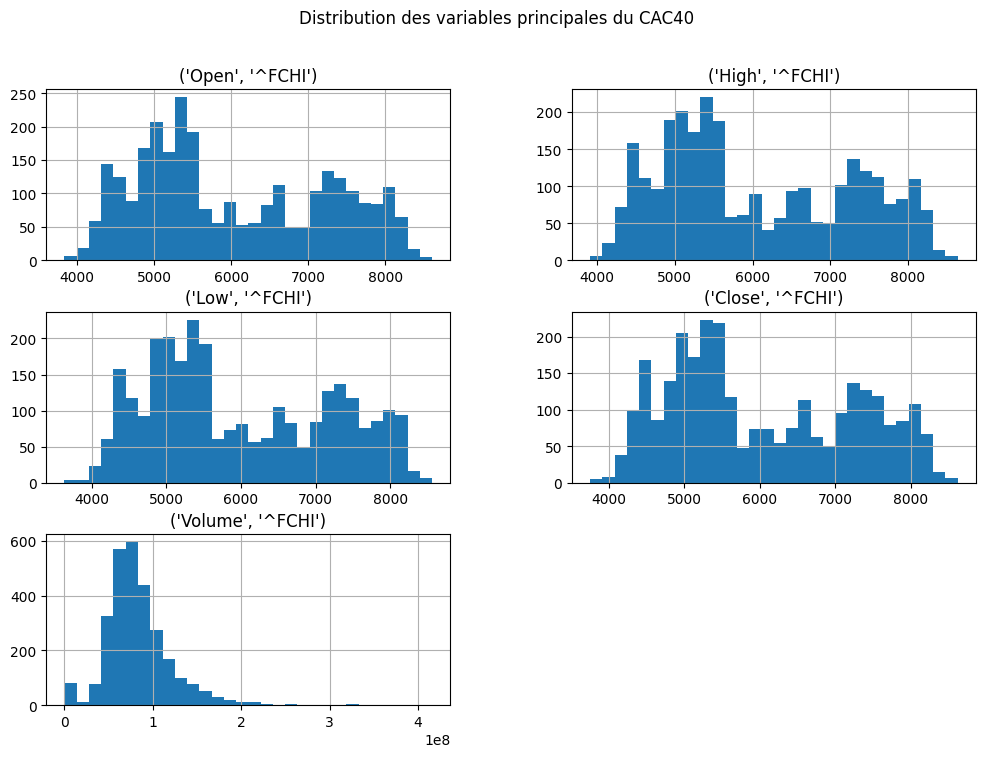

In [ ]:
# CAC40
colonnes = ['Open', 'High', 'Low', 'Close', 'Volume']
df_cac40[colonnes].hist(bins=30, figsize=(12,8))
plt.suptitle('Distribution of main variables of CAC40')
plt.show()

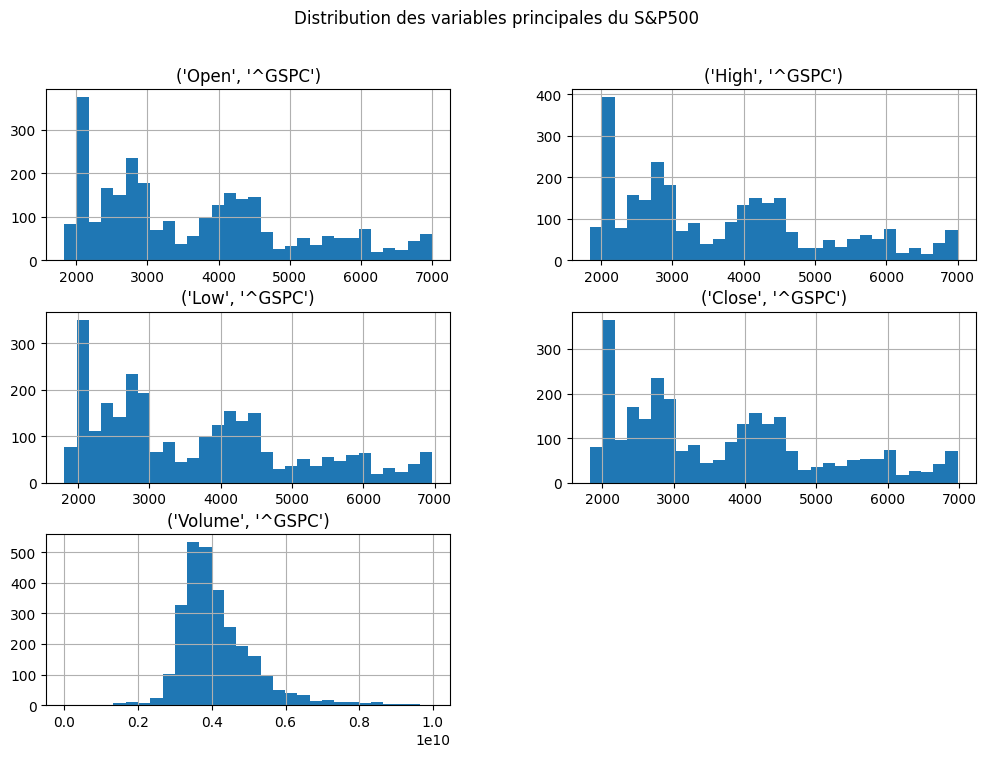

In [ ]:
# S&P500
colonnes = ['Open', 'High', 'Low', 'Close', 'Volume']
df_sp500[colonnes].hist(bins=30, figsize=(12,8))
plt.suptitle('Distribution of main variables of S&P500')
plt.show()

## 10. Visualization of clusters

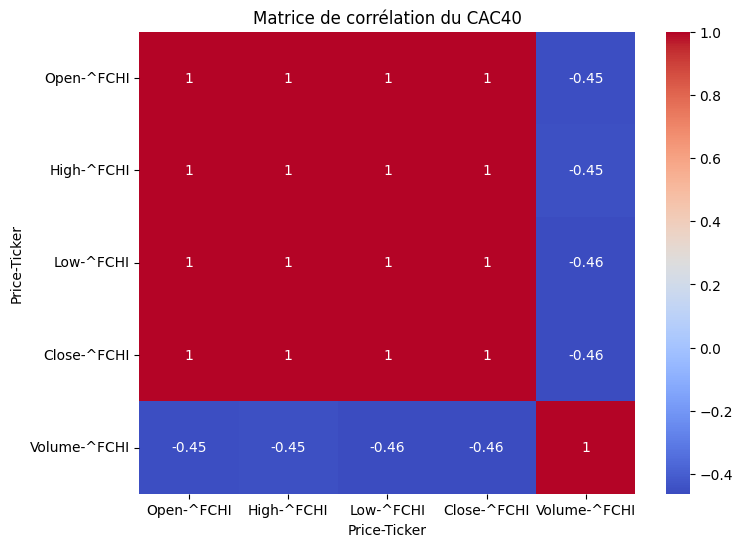

In [ ]:
# CAC40

plt.figure(figsize=(8,6))
sns.heatmap(df_cac40[['Open','High','Low','Close','Volume']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of CAC40')
plt.show()

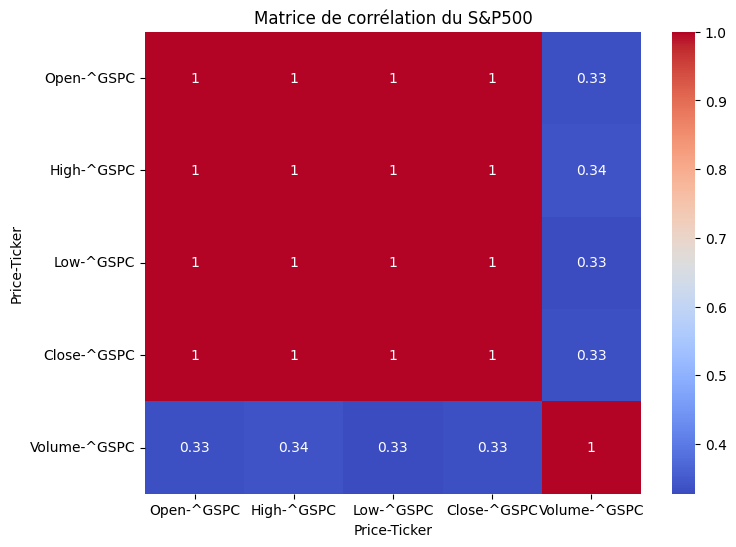

In [ ]:
# S&P500

plt.figure(figsize=(8,6))
sns.heatmap(df_sp500[['Open','High','Low','Close','Volume']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of S&P500')
plt.show()

## 11. Granger causality tests

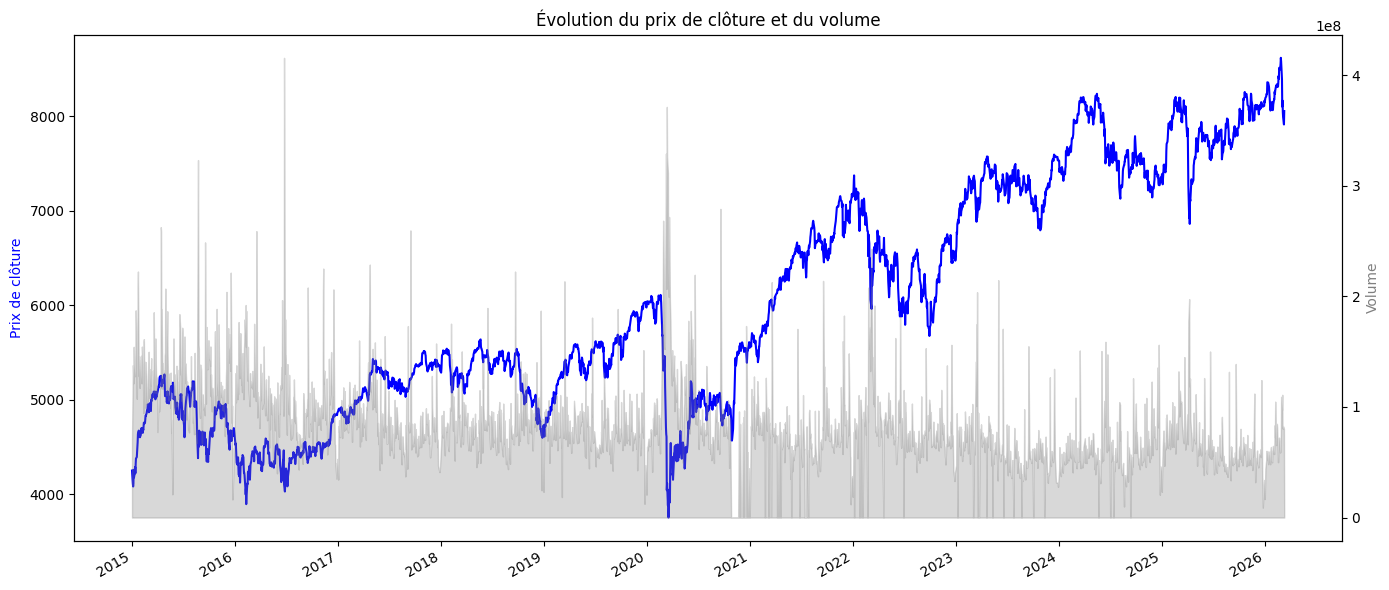

In [ ]:
import matplotlib.dates as mdates

# Ensure the Date column is in datetime format
df_cac40[('Date', '')] = pd.to_datetime(df_cac40[('Date', '')])

# Clean the Volume column (multi-index)
df_cac40 = df_cac40.dropna(subset=[('Volume', '^FCHI')])
df_cac40[('Volume', '^FCHI')] = pd.to_numeric(df_cac40[('Volume', '^FCHI')], errors='coerce')

fig, ax1 = plt.subplots(figsize=(14,6))
ax1.plot(df_cac40[('Date', '')], df_cac40[('Close', '^FCHI')], color='b', label='Close')
ax1.set_ylabel('Closing Price', color='b')
ax2 = ax1.twinx()

# Display the volume as an area plot (more robust than a bar plot)
ax2.fill_between(df_cac40[('Date', '')], df_cac40[('Volume', '^FCHI')].values, color='gray', alpha=0.3, label='Volume')
ax2.set_ylabel('Volume', color='gray')

# Improve the display of dates
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.autofmt_xdate()

plt.title('Evolution of Closing Price and Volume')
fig.tight_layout()
plt.show()

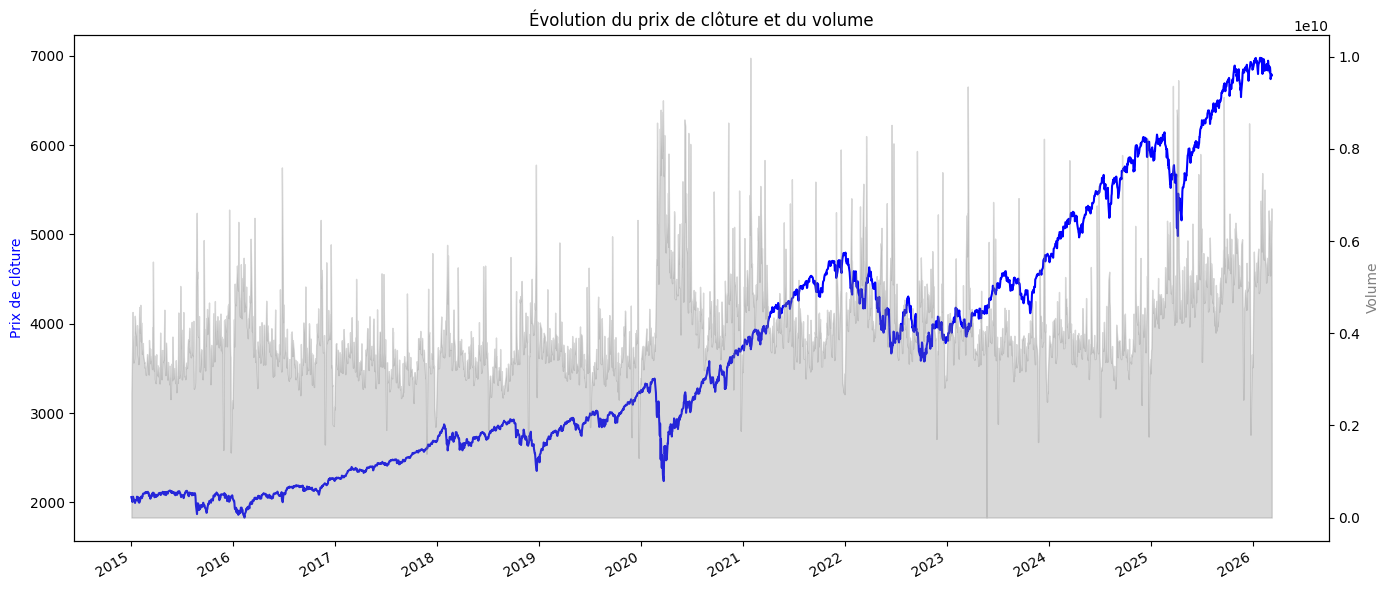

In [ ]:
# S&P500

# Ensure the Date column is in datetime format
df_sp500[('Date', '')] = pd.to_datetime(df_sp500[('Date', '')])

# Clean the Volume column (multi-index)
df_sp500 = df_sp500.dropna(subset=[('Volume', '^GSPC')])
df_sp500[('Volume', '^GSPC')] = pd.to_numeric(df_sp500[('Volume', '^GSPC')], errors='coerce')

fig, ax1 = plt.subplots(figsize=(14,6))
ax1.plot(df_sp500[('Date', '')], df_sp500[('Close', '^GSPC')], color='b', label='Close')
ax1.set_ylabel('Closing Price', color='b')
ax2 = ax1.twinx()

# Display the volume as an area plot (more robust than a bar plot)
ax2.fill_between(df_sp500[('Date', '')], df_sp500[('Volume', '^GSPC')].values, color='gray', alpha=0.3, label='Volume')
ax2.set_ylabel('Volume', color='gray')

# Improve the display of dates
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.autofmt_xdate()

plt.title('Evolution of Closing Price and Volume')
fig.tight_layout()
plt.show()

## 8. Correlation analysis

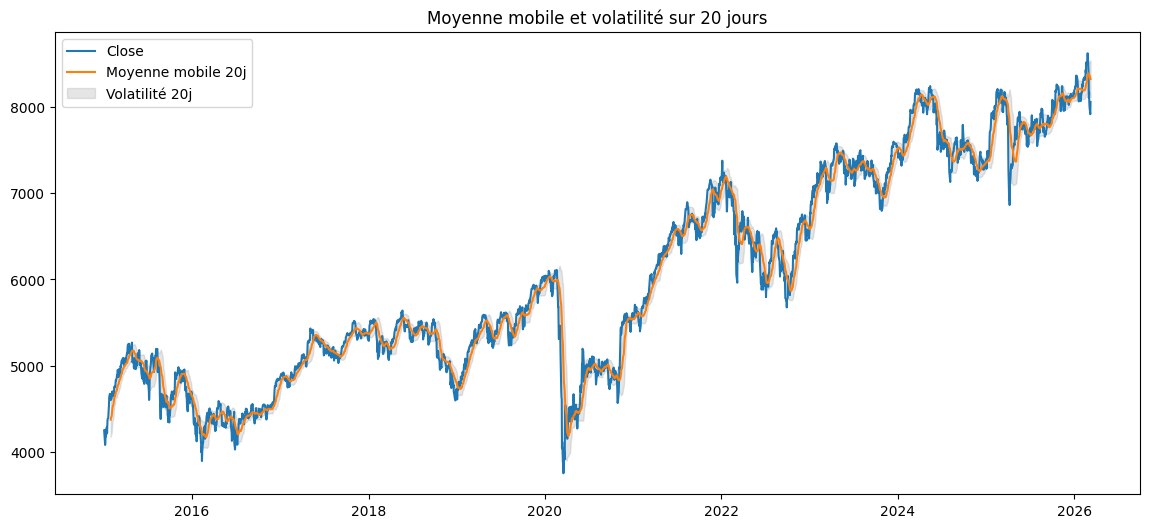

In [ ]:
# CAC40

df_cac40['MA20'] = df_cac40['Close'].rolling(window=20).mean()
df_cac40['Vol20'] = df_cac40['Close'].rolling(window=20).std()
plt.figure(figsize=(14,6))
plt.plot(df_cac40['Date'], df_cac40['Close'], label='Close')
plt.plot(df_cac40['Date'], df_cac40['MA20'], label='Moving Average 20d')
plt.fill_between(df_cac40['Date'], df_cac40['MA20']-df_cac40['Vol20'], df_cac40['MA20']+df_cac40['Vol20'], color='gray', alpha=0.2, label='Volatility 20d')
plt.title('Moving Average and Volatility over 20 Days')
plt.legend()
plt.show()

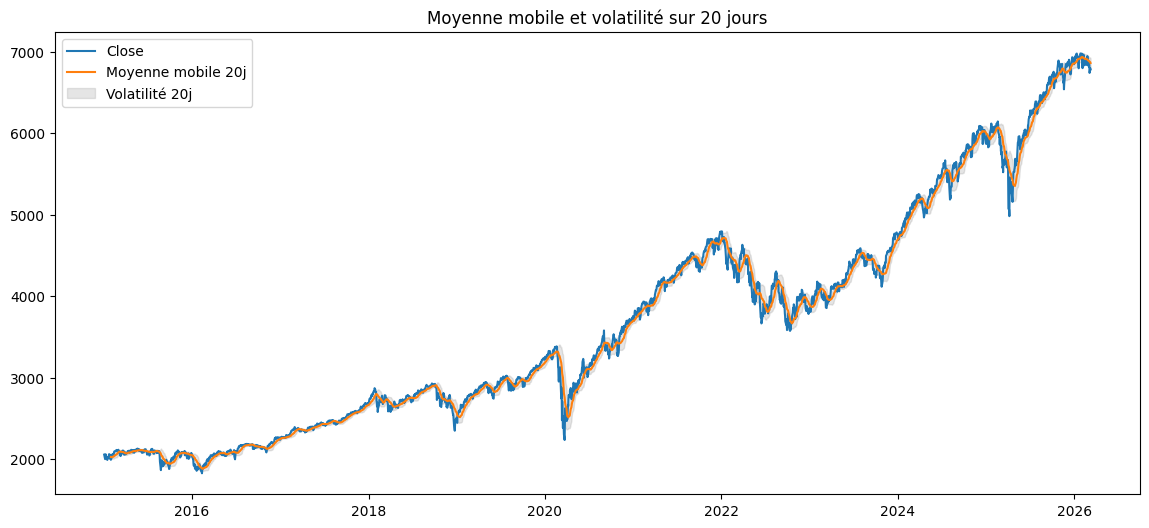

In [ ]:
# S&P500

df_sp500['MA20'] = df_sp500['Close'].rolling(window=20).mean()
df_sp500['Vol20'] = df_sp500['Close'].rolling(window=20).std()
plt.figure(figsize=(14,6))
plt.plot(df_sp500['Date'], df_sp500['Close'], label='Close')
plt.plot(df_sp500['Date'], df_sp500['MA20'], label='Moving Average 20d')
plt.fill_between(df_sp500['Date'], df_sp500['MA20']-df_sp500['Vol20'], df_sp500['MA20']+df_sp500['Vol20'], color='gray', alpha=0.2, label='Volatility 20d')
plt.title('Moving Average and Volatility over 20 Days')
plt.legend()
plt.show()

## 9. Time series decomposition

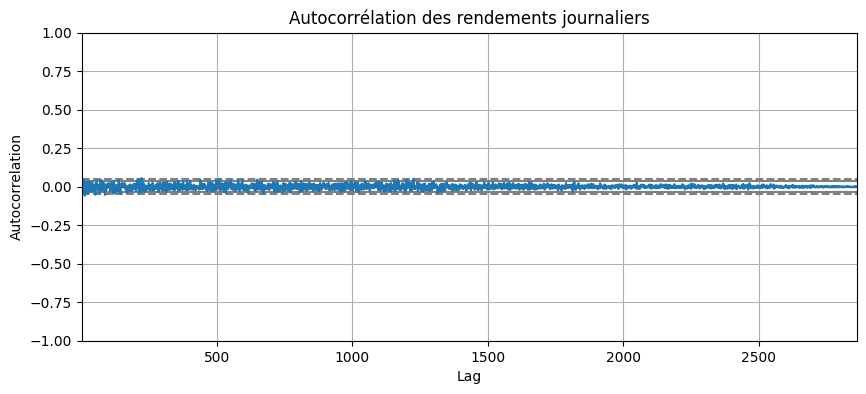

In [ ]:
# CAC40

df_cac40['Return'] = df_cac40['Close'].pct_change()
plt.figure(figsize=(10,4))
autocorrelation_plot(df_cac40['Return'].dropna())
plt.title("Autocorrelation of Daily Returns")
plt.show()

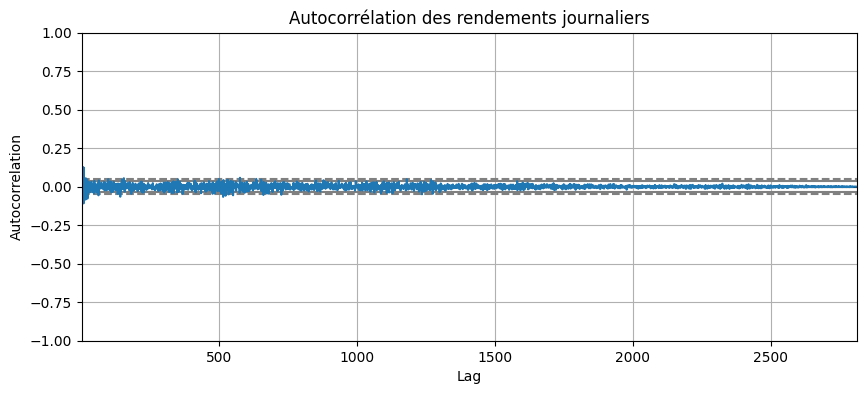

In [ ]:
# S&P500

df_sp500['Return'] = df_sp500['Close'].pct_change()
plt.figure(figsize=(10,4))
autocorrelation_plot(df_sp500['Return'].dropna())
plt.title("Autocorrelation of Daily Returns")
plt.show()

## 12. Detection and  visualisation of outliers
Identify extreme values in daily returns.

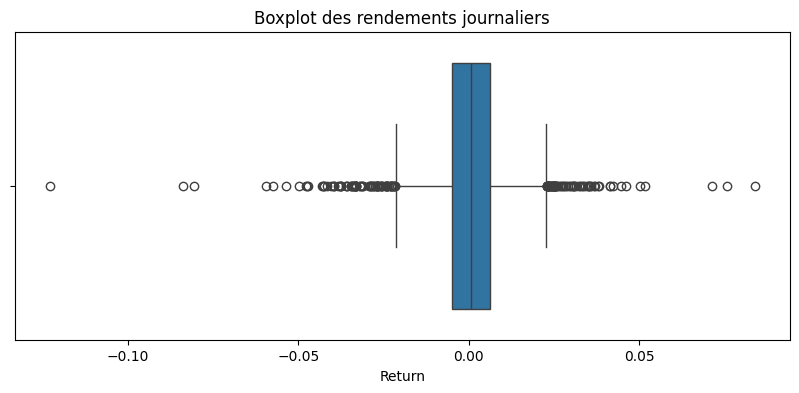

Outliers détectés :
Price        Date    Return
Ticker                     
4      2015-01-08  0.035855
118    2015-06-22  0.038053
123    2015-06-29 -0.037427
163    2015-08-24 -0.053451
164    2015-08-25  0.041383
166    2015-08-27  0.034910
193    2015-10-05  0.035439
236    2015-12-03 -0.035784
283    2016-02-11 -0.040503
373    2016-06-20  0.035035
377    2016-06-24 -0.080425
590    2017-04-24  0.041439
1171   2019-08-02 -0.035702
1314   2020-02-24 -0.039446
1323   2020-03-06 -0.041408
1324   2020-03-09 -0.083906
1327   2020-03-12 -0.122768
1329   2020-03-16 -0.057523
1331   2020-03-18 -0.059357
1333   2020-03-20  0.050136
1335   2020-03-24  0.083895
1336   2020-03-25  0.044688
1338   2020-03-27 -0.042277
1341   2020-04-01 -0.042965
1344   2020-04-06  0.046108
1349   2020-04-15 -0.037620
1353   2020-04-21 -0.037727
1361   2020-05-04 -0.042420
1371   2020-05-18  0.051596
1385   2020-06-05  0.037073
1389   2020-06-11 -0.047061
1461   2020-09-21 -0.037391
1496   2020-11-09  0.075680


In [ ]:
# CAC40

plt.figure(figsize=(10,4))
sns.boxplot(x=df_cac40['Return'].dropna())
plt.title('Daily Boxplot of Returns')
plt.show()

# Display the dates of the largest outliers
outliers = df_cac40.loc[np.abs(df_cac40['Return']) > 3*df_cac40['Return'].std(), ['Date','Return']]
print('Detected Outliers:')
print(outliers)

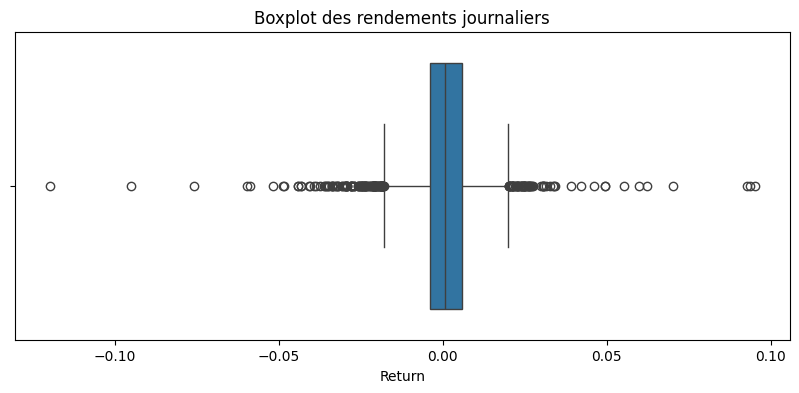

Outliers détectés :
Price        Date    Return
Ticker                     
161    2015-08-24 -0.039414
163    2015-08-26  0.039034
372    2016-06-24 -0.035920
778    2018-02-05 -0.040979
781    2018-02-08 -0.037536
1002   2018-12-26  0.049594
1008   2019-01-04  0.034336
1296   2020-02-27 -0.044163
1298   2020-03-02  0.046039
1300   2020-03-04  0.042203
1301   2020-03-05 -0.033922
1303   2020-03-09 -0.075970
1304   2020-03-10  0.049396
1305   2020-03-11 -0.048868
1306   2020-03-12 -0.095113
1307   2020-03-13  0.092871
1308   2020-03-16 -0.119841
1309   2020-03-17  0.059955
1310   2020-03-18 -0.051831
1312   2020-03-20 -0.043360
1314   2020-03-24  0.093828
1316   2020-03-26  0.062414
1320   2020-04-01 -0.044142
1323   2020-04-06  0.070331
1325   2020-04-08  0.034056
1369   2020-06-11 -0.058944
1428   2020-09-03 -0.035126
1466   2020-10-28 -0.035288
1844   2022-04-29 -0.036285
1848   2022-05-05 -0.035650
1857   2022-05-18 -0.040395
1874   2022-06-13 -0.038768
1937   2022-09-13 -0.043237


In [ ]:
# S&P500

plt.figure(figsize=(10,4))
sns.boxplot(x=df_sp500['Return'].dropna())
plt.title('Daily Boxplot of Returns')
plt.show()

# Display the dates of the largest outliers
outliers = df_sp500.loc[np.abs(df_sp500['Return']) > 3*df_sp500['Return'].std(), ['Date','Return']]
print('Detected Outliers:')
print(outliers)

## 12. Autocorrelation analysis

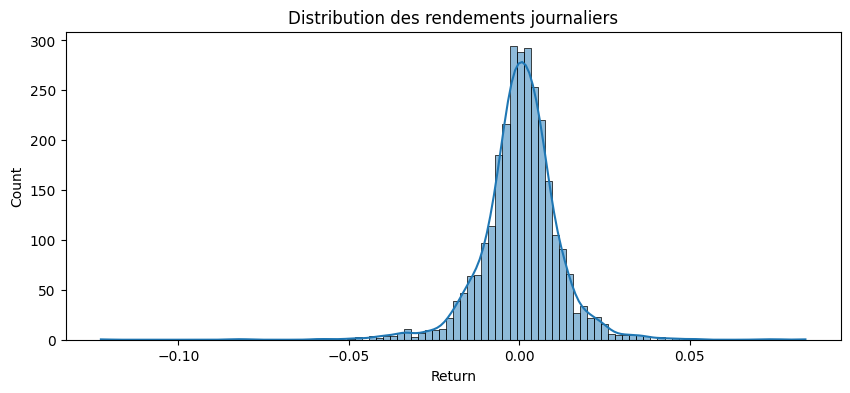

Skewness: -0.6592527608014229
Kurtosis: 10.088526876639262


In [ ]:
# CAC40

plt.figure(figsize=(10,4))
sns.histplot(df_cac40['Return'].dropna(), bins=100, kde=True)
plt.title('Daily Distribution of Returns')
plt.show()

print('Skewness:', df_cac40['Return'].skew())
print('Kurtosis:', df_cac40['Return'].kurtosis())

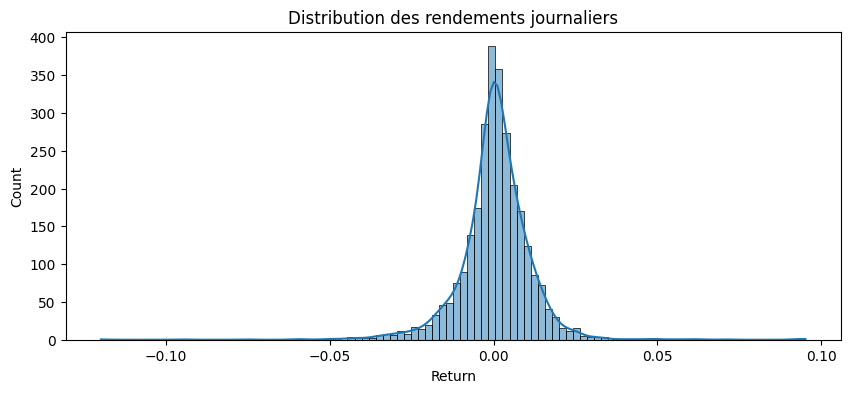

Skewness: -0.36206194035510086
Kurtosis: 15.14177128769753


In [ ]:
# S&P500

plt.figure(figsize=(10,4))
sns.histplot(df_sp500['Return'].dropna(), bins=100, kde=True)
plt.title('Daily Distribution of Returns')
plt.show()

print('Skewness:', df_sp500['Return'].skew())
print('Kurtosis:', df_sp500['Return'].kurtosis())

## 13. Fourier transform

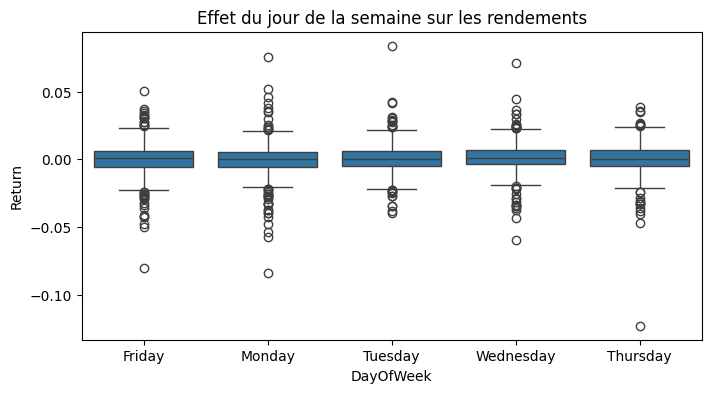

In [ ]:
# CAC40

df_cac40['DayOfWeek'] = pd.to_datetime(df_cac40['Date']).dt.day_name()
plt.figure(figsize=(8,4))
sns.boxplot(x='DayOfWeek', y='Return', data=df_cac40)
plt.title('Day of the Week Effect on Returns')
plt.show()

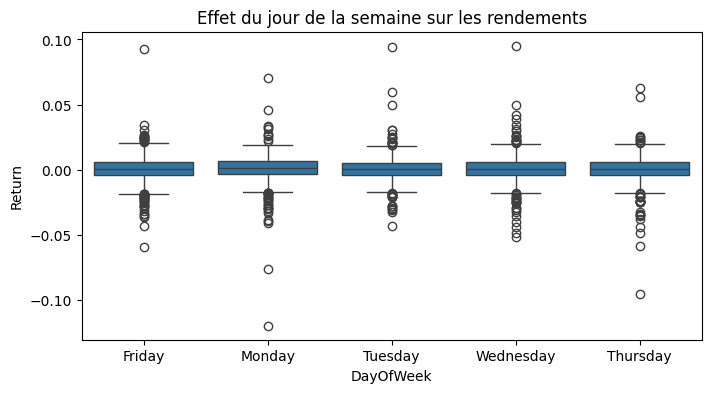

In [ ]:
# S&P500

df_sp500['DayOfWeek'] = pd.to_datetime(df_sp500['Date']).dt.day_name()
plt.figure(figsize=(8,4))
sns.boxplot(x='DayOfWeek', y='Return', data=df_sp500)
plt.title('Day of the Week Effect on Returns')
plt.show()

## 14. Stationarity tests

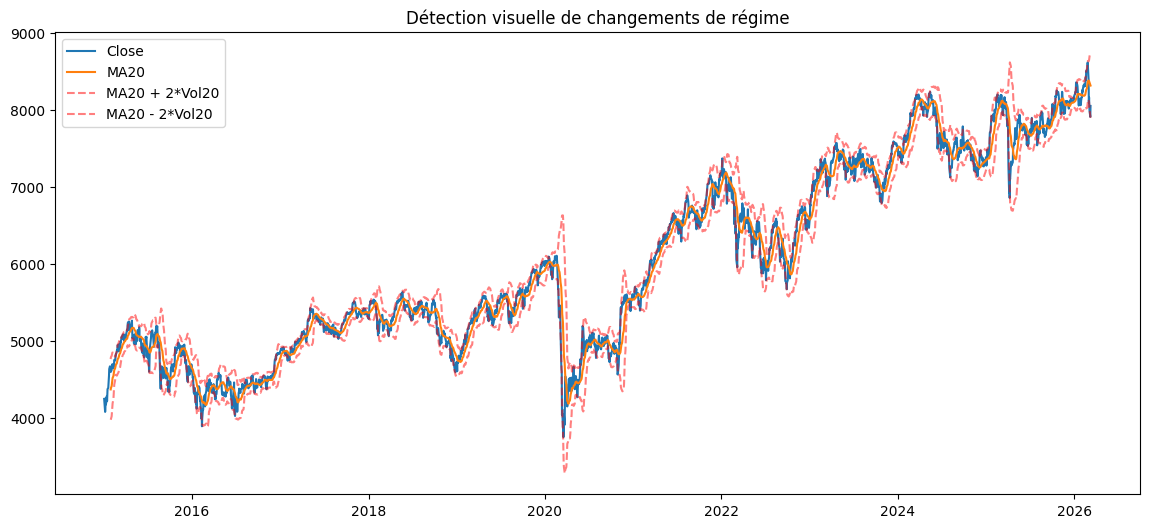

In [ ]:
# CAC40

plt.figure(figsize=(14,6))
plt.plot(df_cac40['Date'], df_cac40['Close'], label='Close')
plt.plot(df_cac40['Date'], df_cac40['MA20'], label='MA20')
plt.plot(df_cac40['Date'], df_cac40['MA20']+2*df_cac40['Vol20'], 'r--', alpha=0.5, label='MA20 + 2*Vol20')
plt.plot(df_cac40['Date'], df_cac40['MA20']-2*df_cac40['Vol20'], 'r--', alpha=0.5, label='MA20 - 2*Vol20')
plt.title('Visual Detection of Regime Changes')
plt.legend()
plt.show()

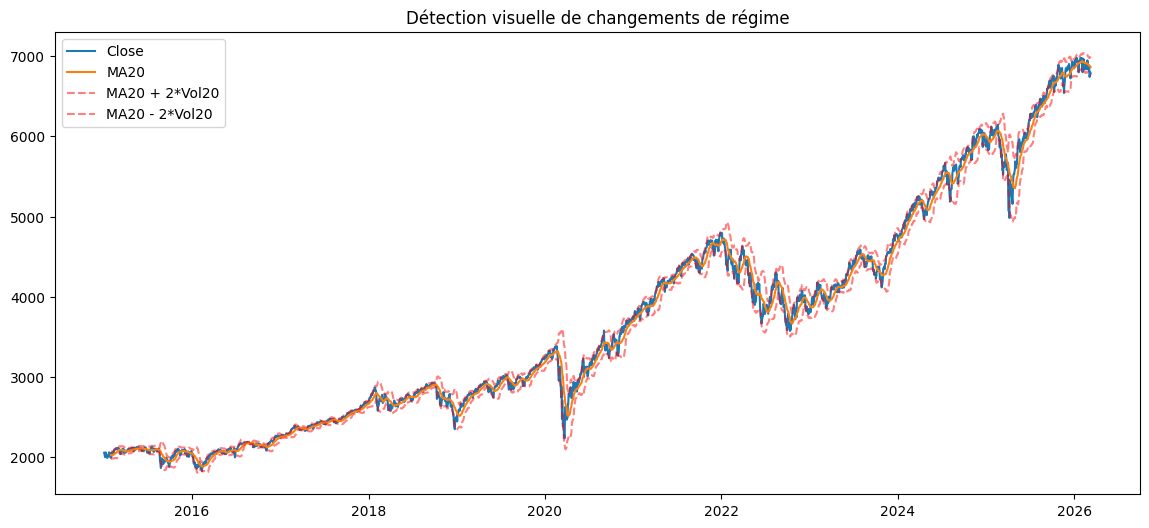

In [ ]:
# S&P500

plt.figure(figsize=(14,6))
plt.plot(df_sp500['Date'], df_sp500['Close'], label='Close')
plt.plot(df_sp500['Date'], df_sp500['MA20'], label='MA20')
plt.plot(df_sp500['Date'], df_sp500['MA20']+2*df_sp500['Vol20'], 'r--', alpha=0.5, label='MA20 + 2*Vol20')
plt.plot(df_sp500['Date'], df_sp500['MA20']-2*df_sp500['Vol20'], 'r--', alpha=0.5, label='MA20 - 2*Vol20')
plt.title('Visual Detection of Regime Changes')
plt.legend()
plt.show()

## 15. Rolling window analysis

In [ ]:
# CAC40

result = adfuller(df_cac40['Close'].dropna())
print('ADF Statistic (Close):', result[0])
print('p-value:', result[1])
for key, value in result[4].items():
    print('Significance Criterion %s: %.3f' % (key, value))

result_ret = adfuller(df_cac40['Return'].dropna())
print('\nADF Statistic (Return):', result_ret[0])
print('p-value:', result_ret[1])
for key, value in result_ret[4].items():
    print('Significance Criterion %s: %.3f' % (key, value))

ADF Statistic (Close): -1.3312966331910046
p-value: 0.6147352521201217
Critère de significativité 1%: -3.433
Critère de significativité 5%: -2.863
Critère de significativité 10%: -2.567

ADF Statistic (Return): -11.25486035941412
p-value: 1.6768567698115258e-20
Critère de significativité 1%: -3.433
Critère de significativité 5%: -2.863
Critère de significativité 10%: -2.567


In [ ]:
# S&P500

result = adfuller(df_sp500['Close'].dropna())
print('ADF Statistic (Close):', result[0])
print('p-value:', result[1])
for key, value in result[4].items():
    print('Significance Criterion %s: %.3f' % (key, value))

result_ret = adfuller(df_sp500['Return'].dropna())
print('\nADF Statistic (Return):', result_ret[0])
print('p-value:', result_ret[1])
for key, value in result_ret[4].items():
    print('Significance Criterion %s: %.3f' % (key, value))

ADF Statistic (Close): 0.5901143923465527
p-value: 0.9873694143788354
Critère de significativité 1%: -3.433
Critère de significativité 5%: -2.863
Critère de significativité 10%: -2.567

ADF Statistic (Return): -17.29373372362378
p-value: 5.683795233892343e-30
Critère de significativité 1%: -3.433
Critère de significativité 5%: -2.863
Critère de significativité 10%: -2.567


## 16. Model evaluation

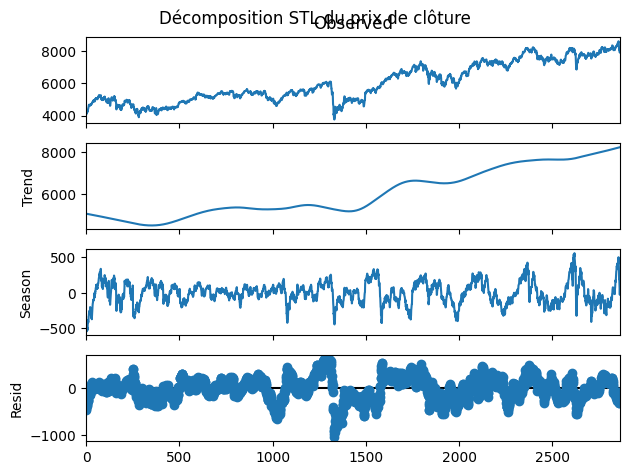

In [ ]:
# CAC40

stl = STL(df_cac40['Close'], period=252)  # 252 open trading days ~ 1 year
res = stl.fit()
res.plot()
plt.suptitle('STL Decomposition of Closing Price')
plt.show()

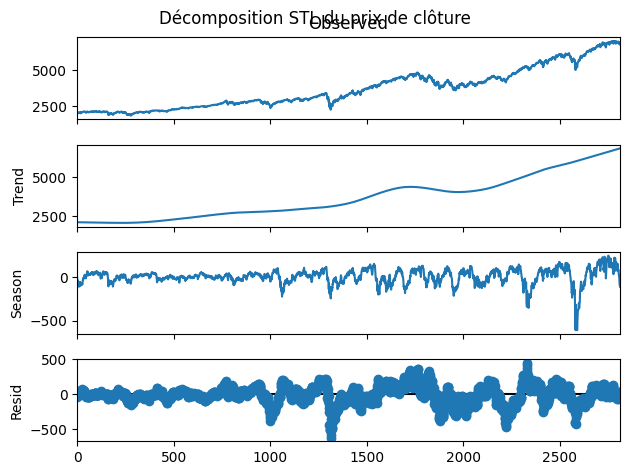

In [ ]:
# S&P500

stl = STL(df_sp500['Close'], period=252)  # 252 open trading days ~ 1 year
res = stl.fit()
res.plot()
plt.suptitle('STL Decomposition of Closing Price')
plt.show()

## 17. Visualization of predictions

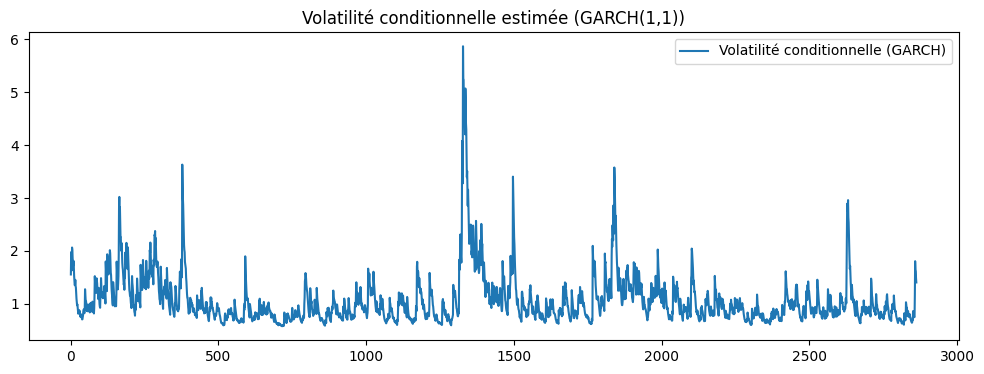

In [ ]:
# CAC40

returns = df_cac40['Return'].dropna() * 100  # GARCH needs percentages
model = arch_model(returns, vol='Garch', p=1, q=1)
res = model.fit(disp='off')
plt.figure(figsize=(12,4))
plt.plot(res.conditional_volatility, label='Conditional Volatility (GARCH)')
plt.title('Estimated Conditional Volatility (GARCH(1,1))')
plt.legend()
plt.show()

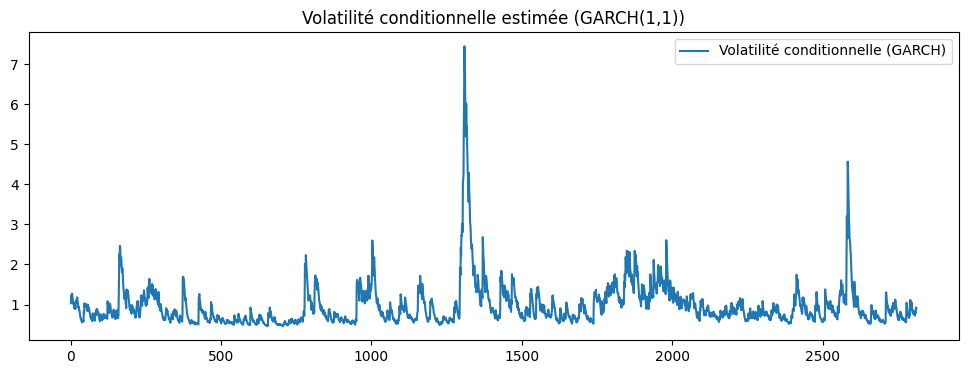

In [ ]:
# S&P500

returns = df_sp500['Return'].dropna() * 100  # GARCH needs percentages
model = arch_model(returns, vol='Garch', p=1, q=1)
res = model.fit(disp='off')
plt.figure(figsize=(12,4))
plt.plot(res.conditional_volatility, label='Conditional Volatility (GARCH)')
plt.title('Estimated Conditional Volatility (GARCH(1,1))')
plt.legend()
plt.show()

## 18. Export results

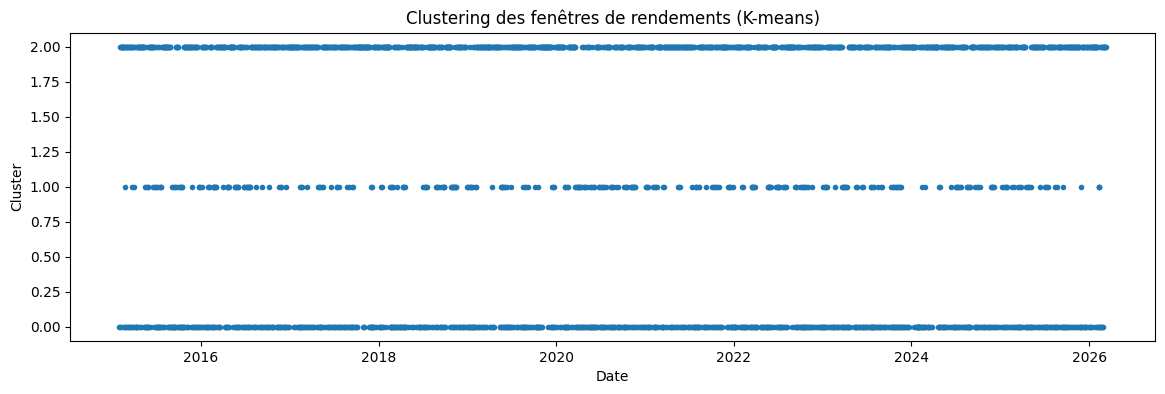

In [ ]:
# CAC40

window = 20  # window size
X = np.lib.stride_tricks.sliding_window_view(df_cac40['Return'].dropna().values, window)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=3, random_state=0)
labels = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(14,4))
plt.plot(df_cac40['Date'][window:], labels, marker='.', linestyle='None')
plt.title('Clustering of Return Windows (K-means)')
plt.xlabel('Date')
plt.ylabel('Cluster')
plt.show()

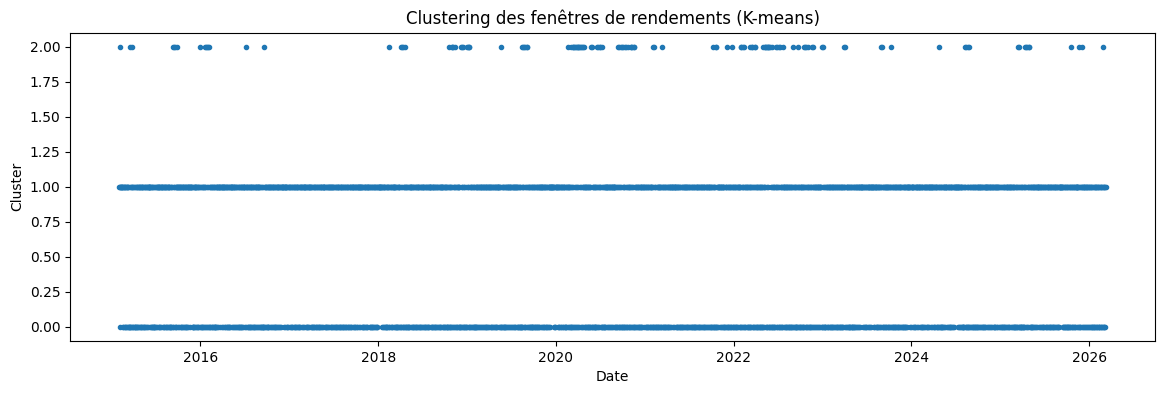

In [ ]:
# S&P500

window = 20  # window size
X = np.lib.stride_tricks.sliding_window_view(df_sp500['Return'].dropna().values, window)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=3, random_state=0)
labels = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(14,4))
plt.plot(df_sp500['Date'][window:], labels, marker='.', linestyle='None')
plt.title('Clustering of Return Windows (K-means)')
plt.xlabel('Date')
plt.ylabel('Cluster')
plt.show()

## 19. Conclusion

In [ ]:
# Example: test between S&P500 and CAC40 (both series must be loaded)
if 'df_cac40' in globals() and 'df_sp500' in globals():
    returns_sp500 = df_sp500['Close'].pct_change().dropna().values
    returns_cac40 = df_cac40['Close'].pct_change().dropna().values
    min_len = min(len(returns_sp500), len(returns_cac40))
    data = np.column_stack([returns_sp500[-min_len:], returns_cac40[-min_len:]])
    print('Granger causality test (S&P500 causes CAC40):')
    grangercausalitytests(data, maxlag=5, verbose=True)
else:
    print("Load both series (df_sp500 and df_cac40) for this test.")

Granger causality test (S&P500 cause CAC40):

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.9135  , p=0.1667  , df_denom=2807, df_num=1
ssr based chi2 test:   chi2=1.9155  , p=0.1664  , df=1
likelihood ratio test: chi2=1.9149  , p=0.1664  , df=1
parameter F test:         F=1.9135  , p=0.1667  , df_denom=2807, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1.2886  , p=0.2758  , df_denom=2804, df_num=2
ssr based chi2 test:   chi2=2.5817  , p=0.2750  , df=2
likelihood ratio test: chi2=2.5805  , p=0.2752  , df=2
parameter F test:         F=1.2886  , p=0.2758  , df_denom=2804, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=4.4454  , p=0.0040  , df_denom=2801, df_num=3
ssr based chi2 test:   chi2=13.3694 , p=0.0039  , df=3
likelihood ratio test: chi2=13.3377 , p=0.0040  , df=3
parameter F test:         F=4.4454  , p=0.0040  , df_denom=2801, df_num=3

Granger Causality
number of lags (no zero)

c:\Users\msagh\Documents\PersonalProjects\market_predictor\venv\lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


## 21. Spectral analysis (FFT)
Detect possible hidden cycles in the closing price series.

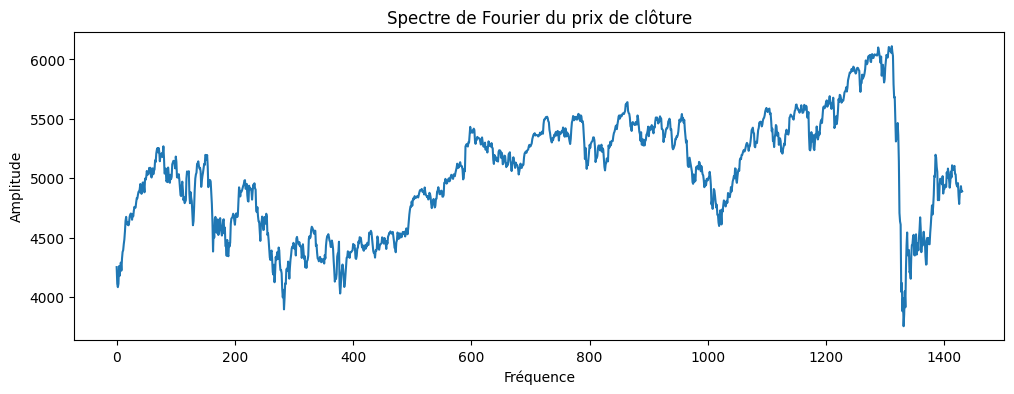

In [ ]:
# CAC40
close = df_cac40['Close'].dropna().values
N = len(close)
T = 1  # 1 day
yf = fftfreq(N, T)[:N//2]
yf = fft(close)
plt.figure(figsize=(12,4))
plt.plot(yf[:N//2].real)
plt.title('Fourier spectrum of closing price')
plt.xlabel('Frequency')
plt.ylabel('Amplitude')
plt.show()

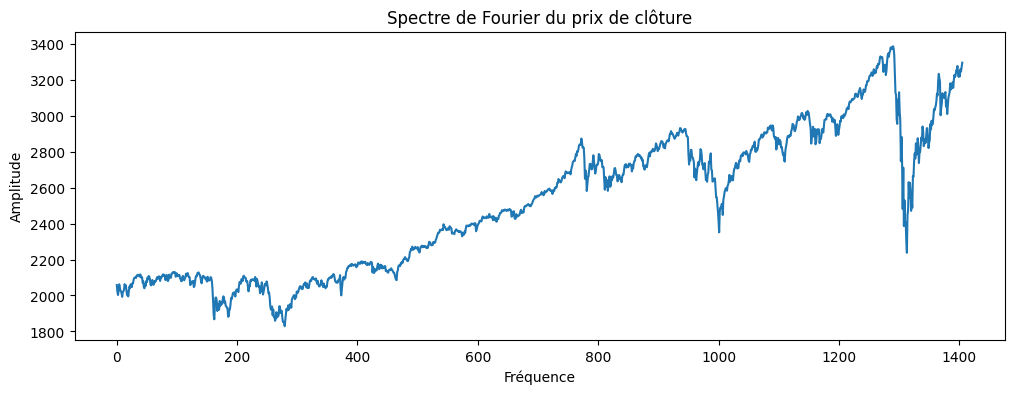

In [ ]:
# S&P500

close = df_sp500['Close'].dropna().values
N = len(close)
T = 1  # 1 day
yf = fftfreq(N, T)[:N//2]
yf = fft(close)
plt.figure(figsize=(12,4))
plt.plot(yf[:N//2].real)
plt.title('Fourier spectrum of closing price')
plt.xlabel('Frequency')
plt.ylabel('Amplitude')
plt.show()